In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# 0. Governing equation

## The equation for particle growth is given by:

$$
v_R(T, R, t, L) = \frac{dR}{dt} = \frac{D(T)}{R \rho_{\text{ice}}} \left( c_{\text{bulk}}(t) - c_{\text{flat}}(T) - \frac{\alpha(T)}{R} - \frac{k(T)}{L^2} \right)
$$

## Continuity Equation


$$
\frac{\partial f(R,t)}{\partial t} + \frac{\partial}{\partial R} \left( f(R, t) v_R \right) = 0
$$

## Conservation Equation


$$
\frac{d c_{\text{bulk}}}{dt} = - 4 \pi \rho_i \int_0^\infty R^2 v_R f(R, t) dR
$$

$$
\alpha(T) = \frac{2 \gamma}{kT} v C_{\text{flat}}(T)
$$

$$
C_{\text{flat}}(T) = \exp \left( -\beta \frac{\Delta h}{T_{\text{eq}} \Delta T} \right) C_{\text{total}}
$$

$$
k(T) = \frac{\alpha P_m}{2}
$$

## Freezing hysteresis
$$
\begin{aligned}
\Delta T &= 2 \xi \kappa \\
\xi &= 37.6~\mathrm{K\,nm} \\
\kappa &= \frac{\eta P_m}{2 L^2}
\end{aligned}
$$

In [48]:
## For sbw AFP at 40 micro M concentration
T_f = 4.1 #[k]
eta_f = 0.95
P_f = 0.012  # micro m
xi = 37.6
sbw_Pf_L2 = T_f / 2 / xi * 2 / eta_f *1000  #[1/micro m]
L = np.sqrt(P_f / sbw_Pf_L2) # micro m

# T_m = 0.4
# eta_m = T_m / xi / sbw_Pm_L2 *1000 #[]

eta_m = 0.69
P_m   = 0.0068 # micro m
sbw_Pm_L2 = P_m / L / L
T_m   = 2 * xi * eta_m * P_m / 2 / L / L / 1000

In [50]:
T_m

1.687473684210526

In [52]:
T_f + T_m

5.787473684210526

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

def time_integration2(f_init, c_bulk_init, R, time_arr, params, save_times):
    """
    Perform time integration to update f, c_bulk, and v_R over time, saving at specified times.

    Parameters:
        f_init (array): Initial distribution function.
        c_bulk_init (float): Initial bulk concentration.
        v_R_init (array): Initial velocity array.
        R (array): Radius array.
        time_arr (array): Time array for the simulation.
        params (dict): Dictionary containing parameter values.
        save_times (array): Array of times at which to save the results.

    Returns:
        f_list (list): List of f values at specified times.
        c_bulk_list (list): List of c_bulk values at specified times.
        v_R_list (list): List of v_R values at specified times.
    """
    # Unpack parameters
    D = params['D']
    rho_ice = params['rho_ice']
    c_flat = params['c_flat']
    alpha = params['alpha']
    delt = params['delt']
    eta_f = params['eta_f']
    eta_m = params['eta_m']
    PfL2 = params['PfL2']
    PmL2 = params['PmL2']

    # Initialize lists to store results
    f_list = []
    c_bulk_list = []
    v_R_list = []

    # Set initial values
    f_t1 = f_init
    c_bulk_t1 = c_bulk_init
    
    condition1 = R > alpha / (c_bulk_t1 - c_flat - alpha * eta_f * PfL2 / 2)
    condition2 = R < alpha / (c_bulk_t1 - c_flat + alpha * eta_m * PmL2 / 2)
    
    v_R_t1 = np.select(
            [condition1, condition2],
            [
                D / (R * rho_ice) * (c_bulk_t1 - c_flat - alpha / R - alpha * eta_f * PfL2 / 2) / 1000,
                D / (R * rho_ice) * (c_bulk_t1 - c_flat - alpha / R + alpha * eta_m * PmL2 / 2) / 1000,
            ],
            default = 0)    
    

    # Time integration loop
    for t in time_arr:
        # Update f using continuity
        f_v_R = f_t1 * v_R_t1
        
        df_v_R_dR = np.gradient(f_v_R, R)


        f_t2 = f_t1 - df_v_R_dR * delt

        # Update c_bulk using conservation
        c_bulk_t2 = c_bulk_t1 - 4 * np.pi * rho_ice * np.trapz(R * R * v_R_t1 * f_t1, R) * delt

        # Update v_R
        
        condition1 = R > alpha / (c_bulk_t2 - c_flat - alpha * eta_f * PfL2 / 2)
        condition2 = R < alpha / (c_bulk_t2 - c_flat + alpha * eta_m * PmL2 / 2)

        
        v_R_t2 = np.select(
                [condition1, condition2],
                [
                    D / (R * rho_ice) * (c_bulk_t2 - c_flat - alpha / R - alpha * eta_f * PfL2 / 2) / 1000,
                    D / (R * rho_ice) * (c_bulk_t2 - c_flat - alpha / R + alpha * eta_m * PmL2 / 2) / 1000,
                ],
                default = 0)

        # Save the updated values if the current time is close to a save time
        if t in save_times:
            f_list.append(f_t2.copy())
            c_bulk_list.append(c_bulk_t2)
            v_R_list.append(v_R_t2.copy())
            
            if alpha / (c_bulk_t2 - c_flat - alpha * eta_f * PmL2 / 2) < 0:
                print('RC1 less than 0 in', PmL2)

            # Plot the current state for visualization
            plt.plot(R, f_t2, label=f"Time = {t:.2f}")

        # Update the previous values for the next iteration
        f_t1 = f_t2
        c_bulk_t1 = c_bulk_t2
        v_R_t1 = v_R_t2

        # Check for NaN values
        if np.isnan(v_R_t2).any():
            print(f"NaN encountered at time t = {t}")
            break

    # Show the plot with labels
    plt.xlabel(r'R [$\mu$m]', size =15)
    plt.ylabel(r'$f [1/ \mu m^4] $', size = 15)
#     plt.title("Evolution of f at specified times")
    plt.legend()
#     plt.grid()
    plt.show()

    return f_list, c_bulk_list, v_R_list


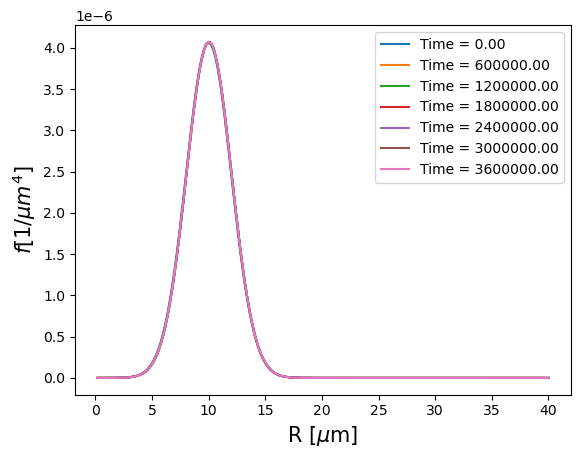

In [71]:
# Initialize parameters and variables
molL_to_microm = 6.02 * 10**8  # Convert mol/L to number/microm^3
delT = 5  # Example temperature difference

params = {
    'D': 1120,  # [microm^2 / s]
    'rho_ice': 910 / 18 * 1000 * 6.02 * 100_000,  # [number / microm^3]
    'c_flat': np.exp(-6000 / 273 * delT / 8.314 / 268) * 55 * molL_to_microm,  # [number / microm^3]
    'alpha': 2 * 30 / 1000 / 8.314 / 268 / 33 * 6.02 * 100 * np.exp(-6000 / 273 * delT / 8.314 / 268) * 55 * molL_to_microm,  # [number / microm^2]
    'delt': 5,  # ms
    'eta_f': 0.95,
    'eta_m': 0.69,
    'PfL2' : 1,  # 1/micro m
    'PmL2' : 1,  # 1/micro m
}

params['eta_f'] = 1
params['eta_m'] = 0.69  
params['PfL2'] = sbw_Pf_L2
params['PmL2'] = sbw_Pm_L2

R = np.linspace(0, 40, 201)[1:]  # Radius array, excluding the first value to avoid zero

meanR = 10  # [microm]
stdR = 2    # [microm]
n = 100  # [number]
V = (170)**3 #[microm]

# Particle size distribution function [1/microm^4]
A = n / (stdR * V * np.sqrt(np.pi) * np.sqrt(2))
f = A * np.exp(-0.5 * ((R - meanR) / stdR) ** 2)

delt = 5  # ms
time_arr = np.arange(0, 60 * 60 * 1000 + delt, delt)

f_init = f  # Initial distribution function
c_bulk_init = (params['c_flat'] + params['alpha'] / meanR + params['alpha'] * params['eta_f'] * params['PfL2'] / 2) * 1.001
# v_R_init = params['D'] / R / params['rho_ice'] * (c_bulk_init - params['c_flat'] - params['alpha'] / R - params['k1'] * params['invL2']) / 1000  # microm/ms

# Define specific times at which to save results
save_times = [0, 1000*60*10, 1000*60*20, 1000*60*30, 1000*60*40, 1000*60*50, 1000*60*60]

# Call the time_integration function
f_list, c_bulk_list, v_R_list = time_integration2(f_init, c_bulk_init, R, time_arr, params, save_times)

R-squared: 0.973


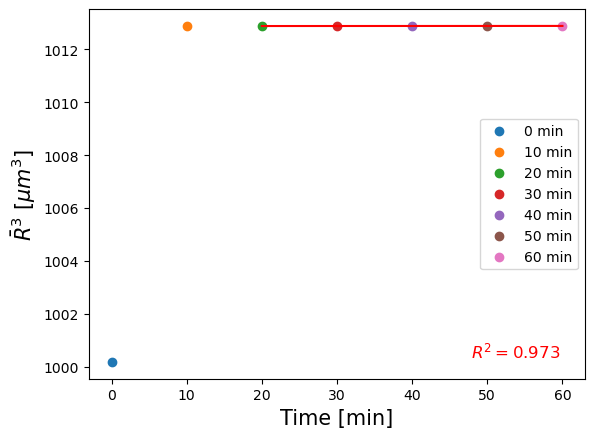

9.914899063565942e-05


In [73]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Assuming f_list and R are already defined, as well as save_times

rcube_list = []
for t in range(len(save_times)):
    # Calculate average R^3 using trapezoidal integration
    average_rcube = (np.trapz(R * f_list[t], R) / np.trapz(f_list[t], R))**3
    rcube_list.append(average_rcube)
    plt.scatter(save_times[t] / 60000, average_rcube, label=f'{save_times[t] // 60000} min')  # Convert time to minutes

# Convert save_times from ms to minutes for plotting
tt_array = np.array(save_times) / 60000
rcube_array = np.array(rcube_list)

# Fit a line to the data (excluding the first two points)
slope, intercept = np.polyfit(tt_array[2:], rcube_array[2:], 1)
fitted_line = slope * tt_array[2:] + intercept

# Plot the fitted line
plt.plot(tt_array[2:], fitted_line, color='red')

# Calculate R-squared value
r_squared = r2_score(rcube_array[2:], fitted_line)
print(f'R-squared: {r_squared:.3f}')

# Labeling the plot
plt.xlabel(r'Time [min]', fontsize=15)
plt.ylabel(r'$\bar{R}^3$ [$\mu m^3$]', fontsize=15)
plt.legend()

# Display R-squared on the plot
plt.text(0.95, 0.05, f'$R^2 = {r_squared:.3f}$', fontsize=12, transform=plt.gca().transAxes,
         verticalalignment='bottom', horizontalalignment='right', color='red')

plt.show()
print(slope)

## Run Varying PmL2

In [76]:
def run_simulations_for_PmL2_list(f_init, c_bulk_init, R, time_arr, params, save_times, L2_multiplier_list):
    """
    Run the time integration for each value in invL2_list, and save the results.

    Parameters:
        f_init (array): Initial distribution function.
        c_bulk_init (float): Initial bulk concentration.
        v_R_init (array): Initial velocity array.
        R (array): Radius array.
        time_arr (array): Time array for the simulation.
        params (dict): Dictionary containing parameter values.
        save_times (array): Array of times at which to save the results.
        L2_multiplier_list (list): List of invL2 multiplier to iterate over.

    Returns:
        results_dict (dict): Dictionary with invL2 values as keys and corresponding results as values.
    """
    results_dict = {}
    base_PfL2 = params['PfL2']
    base_PmL2 = params['PmL2']

    for L2_multiple in L2_multiplier_list:
        print(f"Running simulation for L2_multiplier = {L2_multiple}")
        # Update the parameter
        run_params = params.copy()
        run_params['PfL2'] = base_PfL2 * L2_multiple
        run_params['PmL2'] = base_PmL2 * L2_multiple

        f0 = f_init.copy()

        f_list, c_bulk_list, v_R_list = time_integration2(
            f0, c_bulk_init, R, time_arr, run_params, save_times
        )

        # Store the results
        results_dict[L2_multiple] = {
            'PfL2': run_params['PfL2'],
            'PmL2': run_params['PmL2'],
            'f_list': f_list,
            'c_bulk_list': c_bulk_list,
            'v_R_list': v_R_list,
        }

    return results_dict

In [78]:
# Initialize parameters and variables
molL_to_microm = 6.02 * 10**8  # Convert mol/L to number/microm^3
delT = 5  # Example temperature difference

params = {
    'D': 1120,  # [microm^2 / s]
    'rho_ice': 910 / 18 * 1000 * 6.02 * 100_000,  # [number / microm^3]
    'c_flat': np.exp(-6000 / 273 * delT / 8.314 / 268) * 55 * molL_to_microm,  # [number / microm^3]
    'alpha': 2 * 30 / 1000 / 8.314 / 268 / 33 * 6.02 * 100 * np.exp(-6000 / 273 * delT / 8.314 / 268) * 55 * molL_to_microm,  # [number / microm^2]
    'delt': 5,  # ms
    'eta_f': 1,
    'eta_m': 1,
    'PmL2' : 1,  # 1/micro m
}

params['eta_f'] = 1
params['eta_m'] = 0.69  
params['PfL2'] = sbw_Pf_L2
params['PmL2'] = sbw_Pm_L2

R = np.linspace(0, 40, 201)[1:]  # Radius array, excluding the first value to avoid zero

meanR = 10  # [microm]
stdR = 2    # [microm]
n = 100  # [number]
V = (170)**3 #[microm]

# Particle size distribution function [1/microm^4]
A = n / (stdR * V * np.sqrt(np.pi) * np.sqrt(2))
f = A * np.exp(-0.5 * ((R - meanR) / stdR) ** 2)

delt = 5  # ms
time_arr = np.arange(0, 60 * 60 * 1000 + delt, delt)

f_init = f  # Initial distribution function
c_bulk_init = (params['c_flat'] + params['alpha'] / meanR + params['alpha'] * params['eta_f'] * params['PfL2'] / 2) * 1.00001
# v_R_init = params['D'] / R / params['rho_ice'] * (c_bulk_init - params['c_flat'] - params['alpha'] / R - params['k1'] * params['invL2']) / 1000  # microm/ms

# Define specific times at which to save results
save_times = [0, 1000*60*10, 1000*60*20, 1000*60*30, 1000*60*40, 1000*60*50, 1000*60*60]
# # Example: Accessing results for a specific invL2
# example_PmL2 = PmL2_list[0]
# f_list_example = results_dict[example_PmL2]['f_list']
# c_bulk_list_example = results_dict[example_PmL2]['c_bulk_list']
# v_R_list_example = results_dict[example_PmL2]['v_R_list']

Running simulation for L2_multiplier = 1e-06


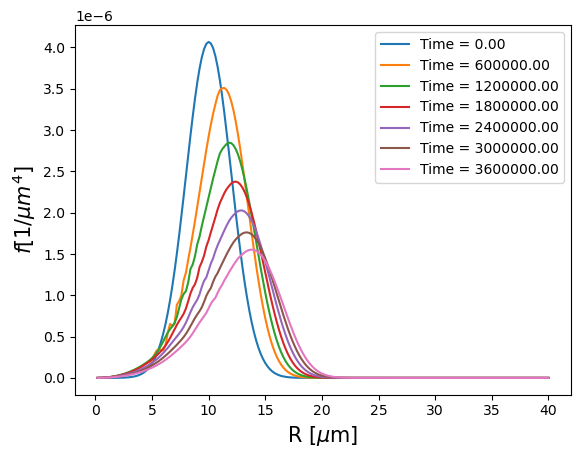

Running simulation for L2_multiplier = 1e-05


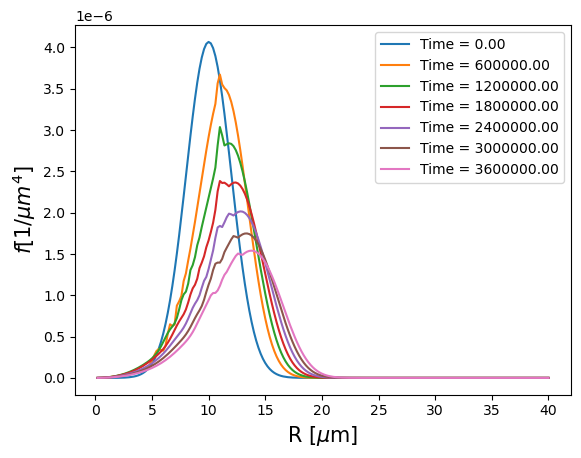

Running simulation for L2_multiplier = 3e-05


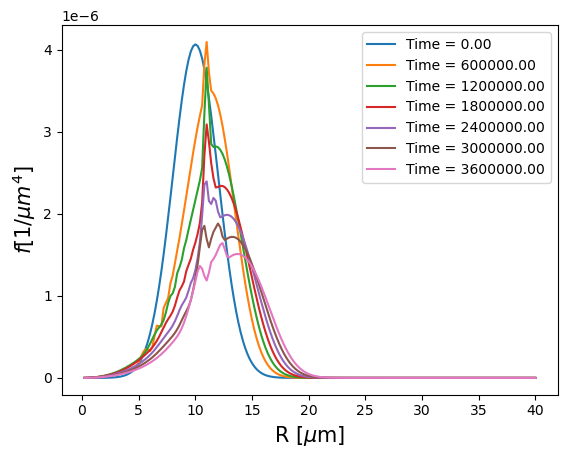

Running simulation for L2_multiplier = 5e-05


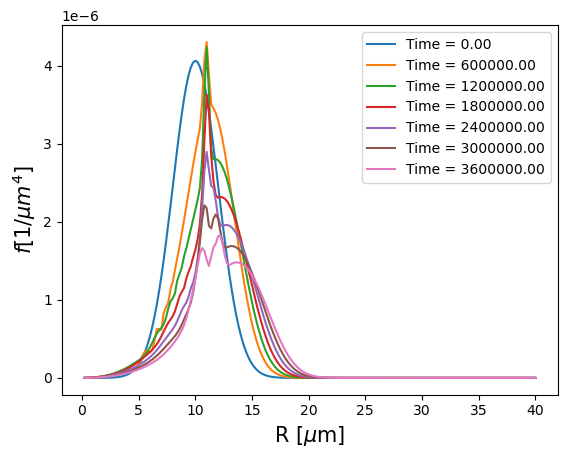

Running simulation for L2_multiplier = 0.0001


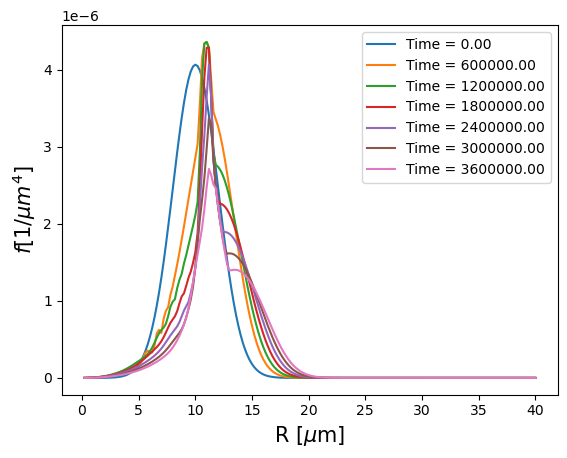

Running simulation for L2_multiplier = 0.0002


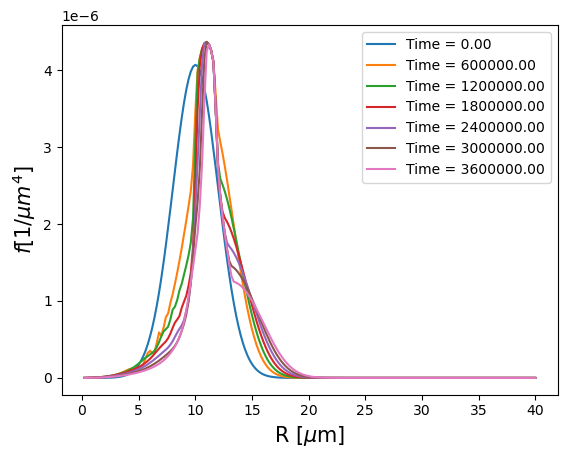

Running simulation for L2_multiplier = 0.0005


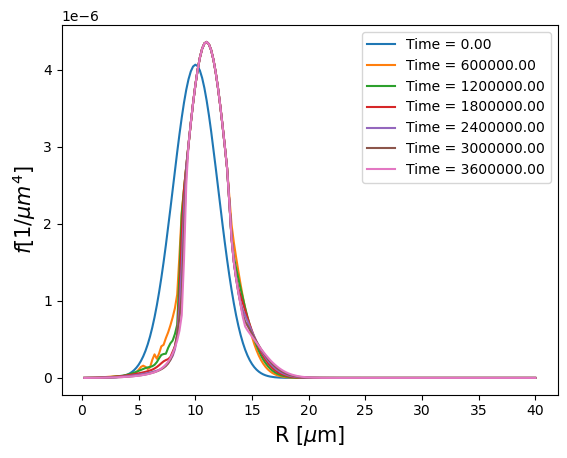

Running simulation for L2_multiplier = 0.001


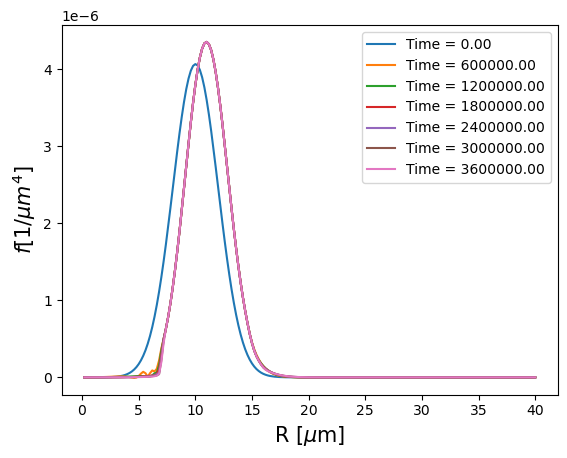

Running simulation for L2_multiplier = 0.005


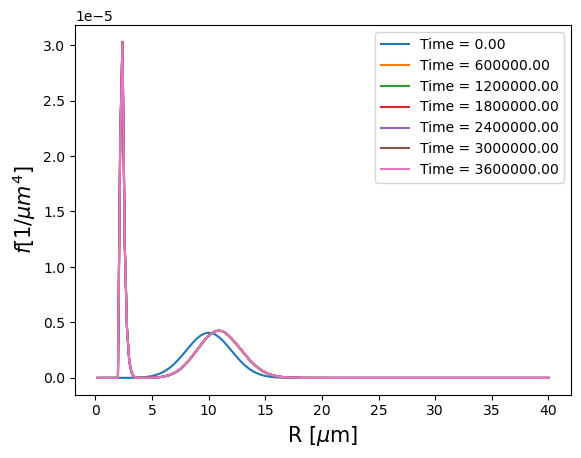

Running simulation for L2_multiplier = 0.01


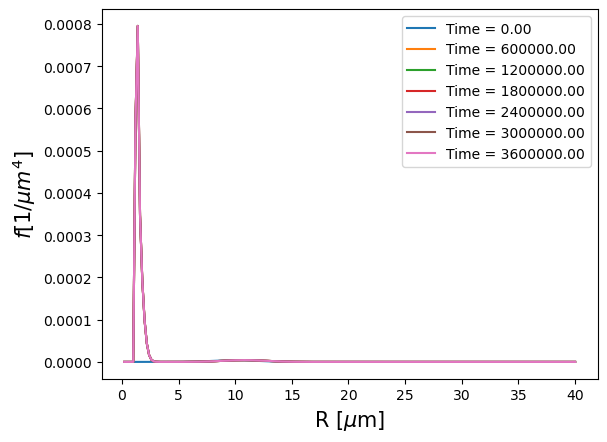

Running simulation for L2_multiplier = 0.1


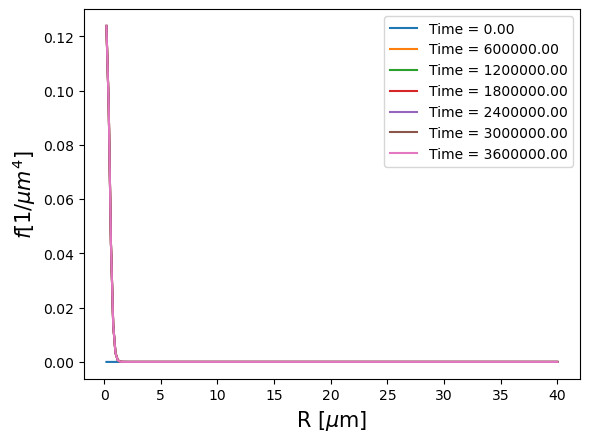

Running simulation for L2_multiplier = 1


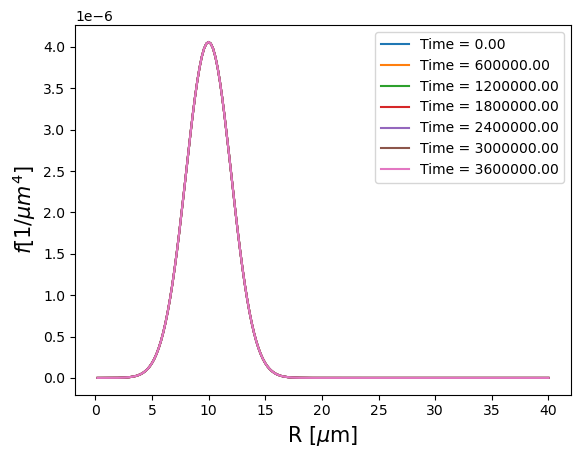

In [85]:
L2_multiplier_list = [0.000001, 0.00001, 0.00003, 0.00005, 0.0001, 0.0002, 0.0005, 0.001, 0.005,0.01, 0.1, 1]

results_dict = run_simulations_for_PmL2_list(f_init, c_bulk_init, R, time_arr, params, save_times, L2_multiplier_list)

L2_multiplier: 1e-06, Slope: 1.744e+01 ± 4.004e-01, R²: 0.998


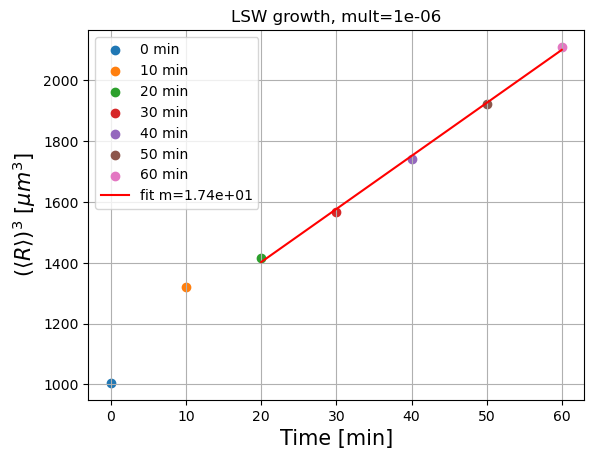

L2_multiplier: 1e-05, Slope: 1.674e+01 ± 3.089e-01, R²: 0.999


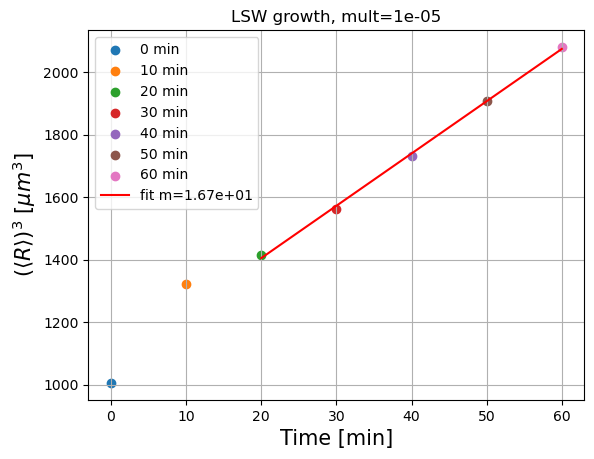

L2_multiplier: 3e-05, Slope: 1.540e+01 ± 1.792e-01, R²: 1.000


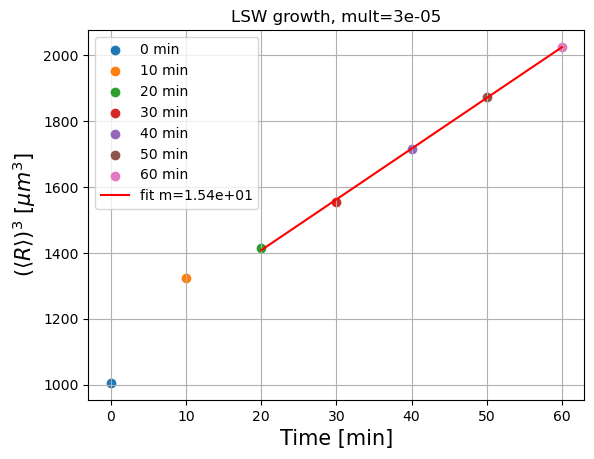

L2_multiplier: 5e-05, Slope: 1.421e+01 ± 1.483e-01, R²: 1.000


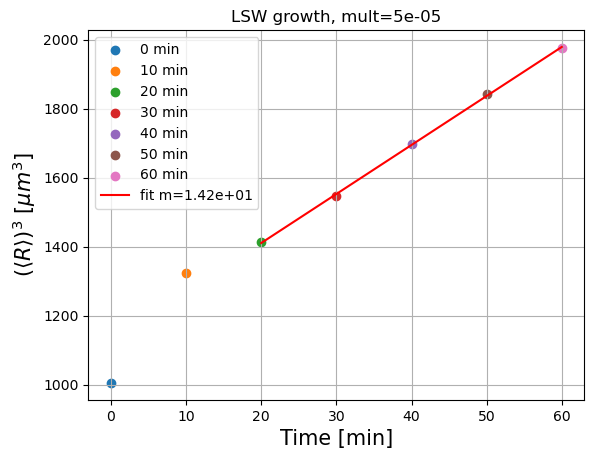

L2_multiplier: 0.0001, Slope: 1.175e+01 ± 2.534e-01, R²: 0.999


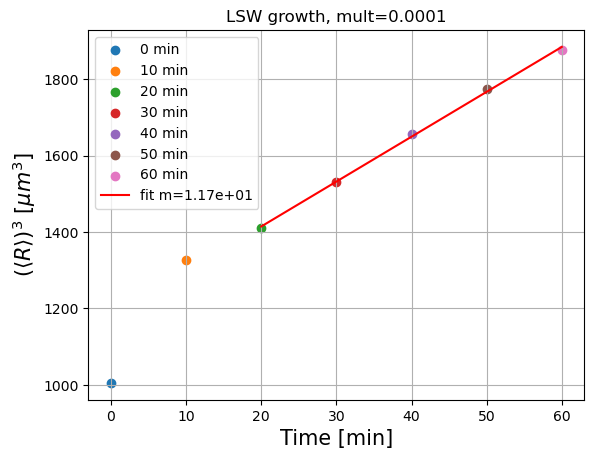

L2_multiplier: 0.0002, Slope: 8.104e+00 ± 3.964e-01, R²: 0.993


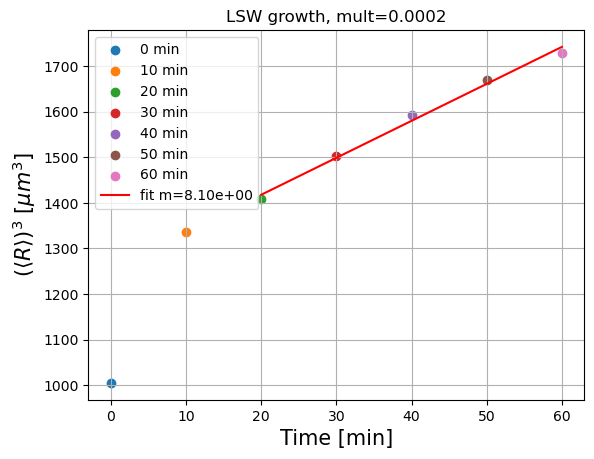

L2_multiplier: 0.0005, Slope: 2.391e+00 ± 2.905e-01, R²: 0.958


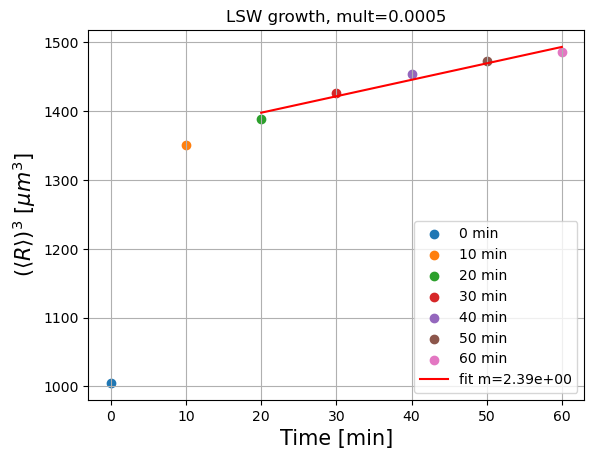

L2_multiplier: 0.001, Slope: 2.543e-01 ± 3.214e-02, R²: 0.954


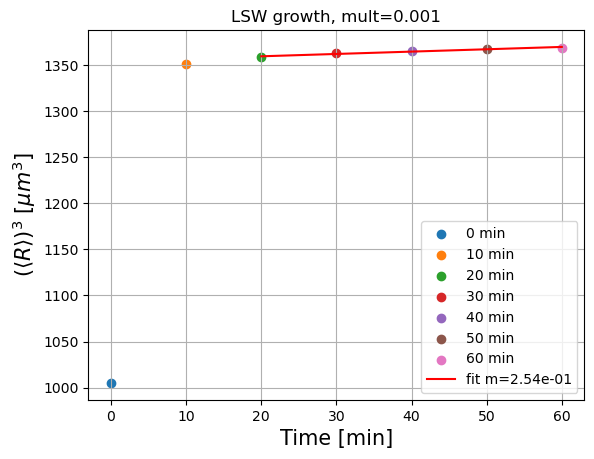

L2_multiplier: 0.005, Slope: 2.686e-02 ± 1.902e-03, R²: 0.985


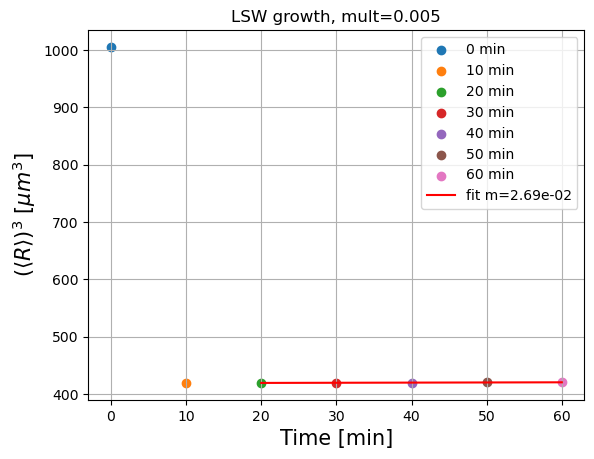

L2_multiplier: 0.01, Slope: 1.488e-07 ± 1.511e-08, R²: 0.970


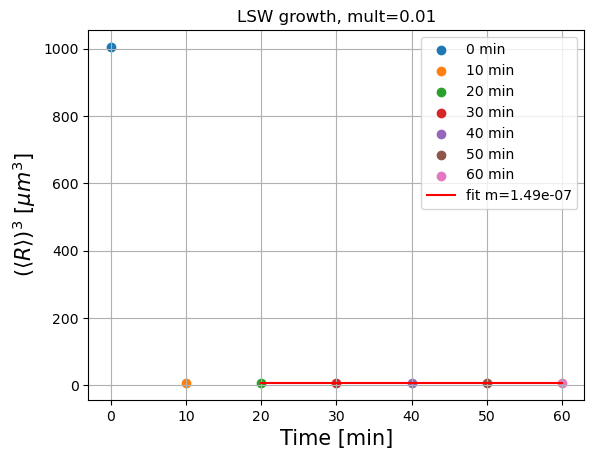

L2_multiplier: 0.1, Slope: 7.894e-11 ± 7.641e-12, R²: 0.973


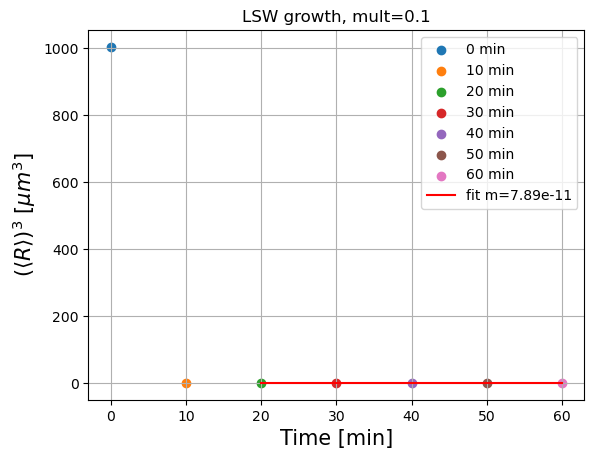

L2_multiplier: 1, Slope: 9.901e-05 ± 9.579e-06, R²: 0.973


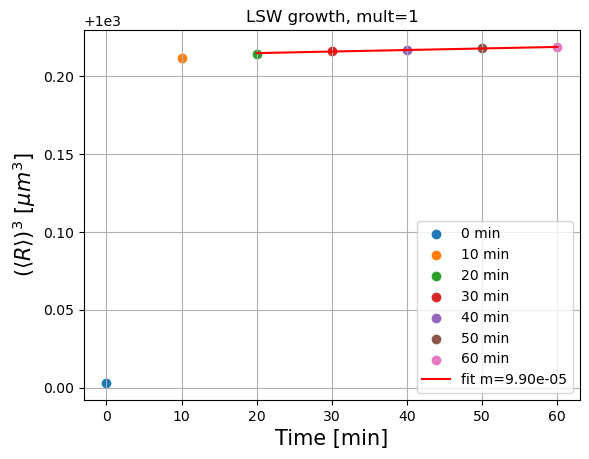

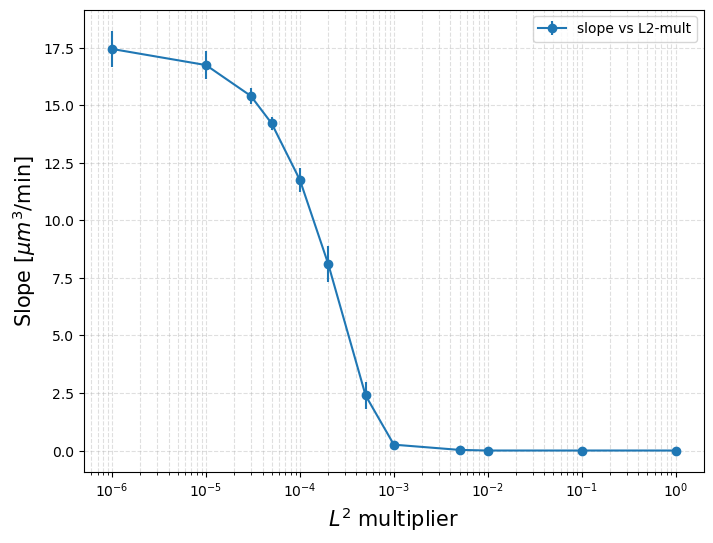

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

def calculate_slope_for_each_L2mult_with_error(results_dict, R, save_times):
    """
    For each L2-multiplier in results_dict:
      1) compute <R>(t) = ∫ R f dR / ∫ f dR
      2) use (<R>(t))^3 as the LSW quantity
      3) fit line to late-time part and return slope + error
    LSW assumption used here: ( <R> )^3 ~ k t
    """
    slopes_dict = {}
    slope_errors_dict = {}

    # ms → min
    tt_array = np.array(save_times) / 60000.0

    for L2_mult, results in results_dict.items():
        f_list = results['f_list']

        Rbar_cube_list = []
        for t_idx in range(len(save_times)):
            f_t = f_list[t_idx]
            denom = np.trapz(f_t, R)         # ∫ f dR
            num   = np.trapz(R * f_t, R)     # ∫ R f dR
            Rbar  = num / denom              # <R>
            Rbar_cube = Rbar**3              # (<R>)^3
            Rbar_cube_list.append(Rbar_cube)

            # raw points
            plt.scatter(tt_array[t_idx], Rbar_cube,
                        label=f'{tt_array[t_idx]:.0f} min')

        Rbar_cube_array = np.array(Rbar_cube_list)

        # late-time 구간만 사용 (여기서는 3번째부터)
        t_fit = tt_array[2:]
        y_fit = Rbar_cube_array[2:]

        # 선형 피팅
        slope, intercept = np.polyfit(t_fit, y_fit, 1)
        slopes_dict[L2_mult] = slope

        # 표준오차
        N = len(t_fit)
        residuals = y_fit - (slope * t_fit + intercept)
        residual_var = np.sum(residuals**2) / (N - 2)
        slope_err = np.sqrt(residual_var / np.sum((t_fit - np.mean(t_fit))**2))
        slope_errors_dict[L2_mult] = slope_err

        # fitted line
        fitted = slope * t_fit + intercept
        r2 = r2_score(y_fit, fitted)

        print(f'L2_multiplier: {L2_mult:.3g}, '
              f'Slope: {slope:.3e} ± {slope_err:.3e}, '
              f'R²: {r2:.3f}')

        # plot
        plt.plot(t_fit, fitted, color='red',
                 label=f'fit m={slope:.2e}')
        plt.xlabel(r'Time [min]', fontsize=15)
        plt.ylabel(r'$(\langle R \rangle)^3$ [$\mu m^3$]', fontsize=15)
        plt.title(f'LSW growth, mult={L2_mult:.3g}')
        plt.legend()
        plt.grid()
        plt.show()

    return slopes_dict, slope_errors_dict


# ----- 사용 -----
slopes_dict, slope_errors_dict = calculate_slope_for_each_L2mult_with_error(
    results_dict, R, save_times
)

# x, y 뽑기
L2_multipliers = list(slopes_dict.keys())
slope_values   = [slopes_dict[m] for m in L2_multipliers]
slope_errors   = [slope_errors_dict[m] for m in L2_multipliers]

plt.figure(figsize=(8, 6))
plt.errorbar(
    L2_multipliers,
    slope_values,
    yerr=2*np.array(slope_errors),
    fmt='o',
    linestyle='-',
    label='slope vs L2-mult'
)
plt.xscale('log')   # 너가 1e-4 ~ 1.0 이런 식으로 줬으니까 로그가 보기 좋음
plt.xlabel(r'$L^2$ multiplier', fontsize=15)
plt.ylabel(r'Slope [$\mu m^3$/min]', fontsize=15)
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.legend()
plt.show()


In [89]:
slope_values

[17.441065707432035,
 16.74104176880504,
 15.401019393231415,
 14.20670333815792,
 11.748111089255879,
 8.10350811403722,
 2.390870544588111,
 0.2542598814600605,
 0.026864848207447105,
 1.4883399305949353e-07,
 7.89369996885326e-11,
 9.900879911009346e-05]

## convert unit for linear approx $\theta \approx c \approx 1/L^2 $
## for $40\mu M , \frac{Pm}{L2} = 109 [1/micro m]$
## We know that $\Delta T$ ~ $c_{AFP}$ ~ $\frac{Pm}{L^2}$
## $C_{AFP2}/C_{AFP1} = (PmL2_2/PmL2_1)$

In [115]:
c_values = 40 * np.array(L2_multiplier_list)

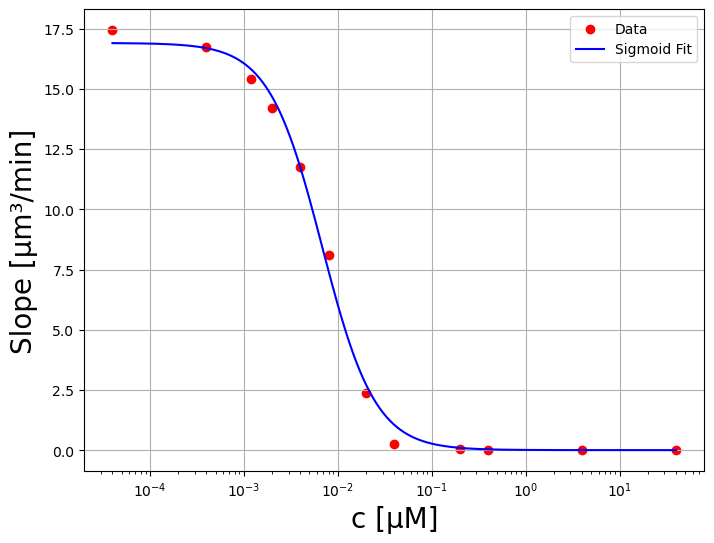

Fitted Parameters: L=16.9074, k=-3.5345, x0=6.8229e-03 (log scale midpoint: -2.1660)


In [117]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Define the sigmoid function
def sigmoid(x, L, k, x0):
    """
    Sigmoid function: L / (1 + exp(-k * (log10(x) - x0)))
    """
    return L / (1 + np.exp(-k * (np.log10(x) - x0)))

# Your data (replace these with your actual values)
# c_values = np.array([1e-4, 1e-3, 1e-2, 1e-1, 1, 10])  # Example x (c_values)
# slope_values = np.array([35, 34, 30, 10, 2, 1])       # Example y (slope_values)

# Fit the sigmoid function to the data
popt, _ = curve_fit(sigmoid, c_values, slope_values, p0=[max(slope_values), 1, np.log10(np.median(c_values))], maxfev=5000)
L, k, x0 = popt

# Generate data for plotting the fitted curve
c_fit = np.logspace(np.log10(min(c_values)), np.log10(max(c_values)), 500)
slope_fit = sigmoid(c_fit, *popt)

# Plot the original data and fitted curve
plt.figure(figsize=(8, 6))
plt.scatter(c_values, slope_values, color='red', label='Data')
plt.plot(c_fit, slope_fit, color='blue', label='Sigmoid Fit')
plt.xscale('log')
plt.xlabel('c [μM]', fontsize=20)
plt.ylabel('Slope [μm³/min]', fontsize=20)
# plt.title('Growth rate', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

# Print fitted parameters
print(f"Fitted Parameters: L={L:.4f}, k={k:.4f}, x0={10**x0:.4e} (log scale midpoint: {x0:.4f})")



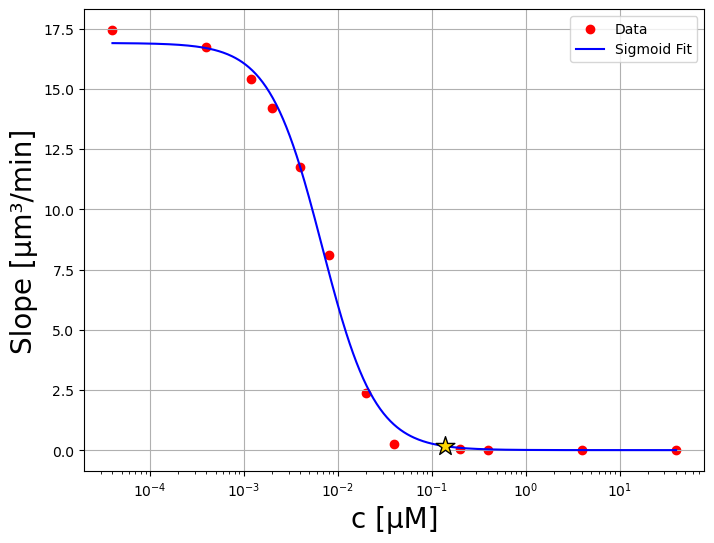

In [131]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Define the sigmoid function
def sigmoid(x, L, k, x0):
    """Sigmoid function: L / (1 + exp(-k * (log10(x) - x0)))"""
    return L / (1 + np.exp(-k * (np.log10(x) - x0)))

# Example data (replace with your real ones)
# c_values = np.array([1e-4, 1e-3, 1e-2, 1e-1, 1, 10])
# slope_values = np.array([35, 34, 30, 10, 2, 1])

# Fit the sigmoid
popt, _ = curve_fit(
    sigmoid,
    c_values,
    slope_values,
    p0=[max(slope_values), 1, np.log10(np.median(c_values))],
    maxfev=5000,
)
L, k, x0 = popt

# Generate fitted curve
c_fit = np.logspace(np.log10(min(c_values)), np.log10(max(c_values)), 500)
slope_fit = sigmoid(c_fit, *popt)

# --- Find the 1% of max point ---
y_max = np.max(slope_fit)
threshold = 0.01 * y_max
idx_1pct = np.argmin(np.abs(slope_fit - threshold))  # closest point
c_1pct = c_fit[idx_1pct]
y_1pct = slope_fit[idx_1pct]

# Plot everything
plt.figure(figsize=(8, 6))
plt.scatter(c_values, slope_values, color="red", label="Data")
plt.plot(c_fit, slope_fit, color="blue", label="Sigmoid Fit")

# Add the star
plt.scatter(c_1pct, y_1pct, color="gold", s=200, marker="*", edgecolor="black", zorder=5)
# plt.text(
#     c_1pct,
#     y_1pct * 1.2,
#     f"★ 1% at c = {c_1pct:.3e}",
#     ha="center",
#     color="goldenrod",
#     fontsize=12,
# )

plt.xscale("log")
plt.xlabel("c [μM]", fontsize=20)
plt.ylabel("Slope [μm³/min]", fontsize=20)
plt.legend()
plt.grid(True)
plt.show()

# print(f"Fitted Parameters: L={L:.4f}, k={k:.4f}, x0={10**x0:.4e} (log10 midpoint={x0:.4f})")
# print(f"1% of max y = {y_1pct:.4f} at c = {c_1pct:.4e}")


## convert unit for linear approx $\theta \approx c^{(1/2)} \approx 1/L^2 $

In [108]:
c_values = 40 * np.array(L2_multiplier_list) * np.array(L2_multiplier_list)

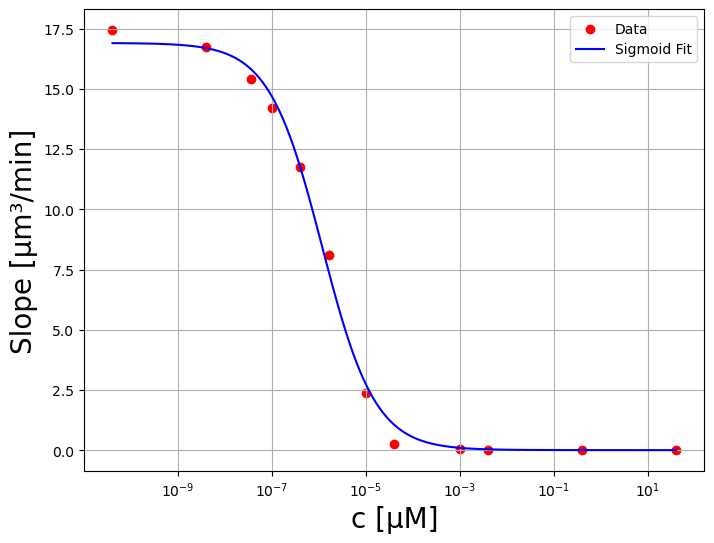

Fitted Parameters: L=16.9074, k=-1.7672, x0=1.1638e-06 (log scale midpoint: -5.9341)


In [111]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Define the sigmoid function
def sigmoid(x, L, k, x0):
    """
    Sigmoid function: L / (1 + exp(-k * (log10(x) - x0)))
    """
    return L / (1 + np.exp(-k * (np.log10(x) - x0)))

# Your data (replace these with your actual values)
# c_values = np.array([1e-4, 1e-3, 1e-2, 1e-1, 1, 10])  # Example x (c_values)
# slope_values = np.array([35, 34, 30, 10, 2, 1])       # Example y (slope_values)

# Fit the sigmoid function to the data
popt, _ = curve_fit(sigmoid, c_values, slope_values, p0=[max(slope_values), 1, np.log10(np.median(c_values))], maxfev=5000)
L, k, x0 = popt

# Generate data for plotting the fitted curve
c_fit = np.logspace(np.log10(min(c_values)), np.log10(max(c_values)), 500)
slope_fit = sigmoid(c_fit, *popt)

# Plot the original data and fitted curve
plt.figure(figsize=(8, 6))
plt.scatter(c_values, slope_values, color='red', label='Data')
plt.plot(c_fit, slope_fit, color='blue', label='Sigmoid Fit')
plt.xscale('log')
plt.xlabel('c [μM]', fontsize=20)
plt.ylabel('Slope [μm³/min]', fontsize=20)
# plt.title('Growth rate', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

# Print fitted parameters
print(f"Fitted Parameters: L={L:.4f}, k={k:.4f}, x0={10**x0:.4e} (log scale midpoint: {x0:.4f})")